In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.image import imread
from astropy.coordinates import SkyCoord
from astropy.coordinates import BarycentricTrueEcliptic
import astropy.units as u
from astropy.time import Time
from astropy.wcs import WCS
from tqdm import tqdm
from glob import glob

from tess_asteroid_ml import *
from tess_asteroid_ml.utils import *
from tess_asteroid_ml.make_TESS_asteroid_db import *

import cartopy.crs as ccrs

from functools import reduce


/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
maglim = 21
PACKAGEDIR

'/Users/jimartin/Work/TESS/tess-asteroid-ml/tess_asteroid_ml'

In [5]:
secstarts = {1: 'Jul 2018', 2: 'Aug 2018', 3: 'Sep 2018', 4: 'Oct 2018',
             5: 'Nov 2018', 6: 'Dec 2018', 7: 'Jan 2019', 8: 'Feb 2019',
             9: 'Feb 2019', 10: 'Mar 2019', 11: 'Apr 2019', 12: 'May 2019',
             13: 'Jun 2019', 14: 'Jul 2019', 15: 'Aug 2019', 16: 'Sep 2019',
             17: 'Oct 2019', 18: 'Nov 2019', 19: 'Nov 2019', 20: 'Dec 2019',
             21: 'Jan 2020', 22: 'Feb 2020', 23: 'Mar 2020', 24: 'Apr 2020',
             25: 'May 2020', 26: 'Jun 2020', 27: 'Jul 2020', 28: 'Jul 2020',
             29: 'Aug 2020', 30: 'Sep 2020', 31: 'Oct 2020', 32: 'Nov 2020',
             33: 'Dec 2020', 34: 'Jan 2021', 35: 'Feb 2021', 36: 'Mar 2021',
             37: 'Apr 2021', 38: 'Apr 2021', 39: 'May 2021', 40: 'Jun 2021',
             41: 'Jul 2021', 42: 'Aug 2021', 43: 'Sep 2021', 44: 'Oct 2021',
             45: 'Nov 2021', 46: 'Dec 2021', 47: 'Dec 2021', 48: 'Jan 2022',
             49: 'Feb 2022', 50: 'Mar 2022', 51: 'Apr 2022', 52: 'May 2022',
             53: 'Jun 2022', 54: 'Jul 2022', 55: 'Aug 2022', 56: 'Sep 2022',
             57: 'Sep 2022', 58: 'Oct 2022', 59: 'Nov 2022', 60: 'Dec 2022',
             61: 'Jan 2023', 62: 'Feb 2023', 63: 'Mar 2023', 64: 'Apr 2023',
             65: 'May 2023', 66: 'Jun 2023', 67: 'Jul 2023', 68: 'Jul 2023',
             69: 'Aug 2023', 70: 'Sep 2023', 71: 'Oct 2023', 72: 'Nov 2023',
             73: 'Dec 2023', 74: 'Jan 2024', 75: 'Jan 2024', 76: 'Feb 2024',
             77: 'Mar 2024', 78: 'Apr 2024', 79: 'May 2024', 80: 'Jun 2024',
             81: 'Jul 2024', 82: 'Aug 2024', 83: 'Sep 2024'}
secends = {1: 'Aug 2018', 2: 'Sep 2018', 3: 'Oct 2018', 4: 'Nov 2018',
           5: 'Dec 2018', 6: 'Jan 2019', 7: 'Feb 2019', 8: 'Feb 2019',
           9: 'Mar 2019', 10: 'Apr 2019', 11: 'May 2019', 12: 'Jun 2019',
           13: 'Jul 2019', 14: 'Aug 2019', 15: 'Sep 2019', 16: 'Oct 2019',
           17: 'Nov 2019', 18: 'Nov 2019', 19: 'Dec 2019', 20: 'Jan 2020',
           21: 'Feb 2020', 22: 'Mar 2020', 23: 'Apr 2020', 24: 'May 2020',
           25: 'Jun 2020', 26: 'Jul 2020', 27: 'Jul 2020', 28: 'Aug 2020',
           29: 'Sep 2020', 30: 'Oct 2020', 31: 'Nov 2020', 32: 'Dec 2020',
           33: 'Jan 2021', 34: 'Feb 2021', 35: 'Mar 2021', 36: 'Apr 2021',
           37: 'Apr 2021', 38: 'May 2021', 39: 'Jun 2021', 40: 'Jul 2021',
           41: 'Aug 2021', 42: 'Sep 2021', 43: 'Oct 2021', 44: 'Nov 2021',
           45: 'Dec 2021', 46: 'Dec 2021', 47: 'Jan 2022', 48: 'Feb 2022',
           49: 'Mar 2022', 50: 'Apr 2022', 51: 'May 2022', 52: 'Jun 2022',
           53: 'Jul 2022', 54: 'Aug 2022', 55: 'Sep 2022', 56: 'Sep 2022',
           57: 'Oct 2022', 58: 'Nov 2022', 59: 'Dec 2022', 60: 'Jan 2023',
           61: 'Feb 2023', 62: 'Mar 2023', 63: 'Apr 2023', 64: 'May 2023',
           65: 'Jun 2023', 66: 'Jul 2023', 67: 'Jul 2023', 68: 'Aug 2023',
           69: 'Sep 2023', 70: 'Oct 2023', 71: 'Nov 2023', 72: 'Dec 2023',
           73: 'Jan 2024', 74: 'Jan 2024', 75: 'Feb 2024', 76: 'Mar 2024',
           77: 'Apr 2024', 78: 'May 2024', 79: 'Jun 2024', 80: 'Jul 2024',
           81: 'Aug 2024', 82: 'Sep 2024', 83: 'Oct 2024'}

In [6]:
def projection_param(hemisphere):

    if hemisphere == 'south':
        cenlon = 90.
        cenlat = -90.#-66.560708333333#
        projection = ccrs.AzimuthalEquidistant(central_longitude=cenlon, central_latitude=cenlat)    
        wrap = False#True#
        title = "NASA TESS's View\nof the Southern\nHemisphere"
        min_lat, max_lat = -90, 0.
    
    elif hemisphere == 'north':
        cenlon = -90.
        cenlat = 90.#-66.560708333333#
        projection = ccrs.AzimuthalEquidistant(central_longitude=cenlon, central_latitude=cenlat)    
        wrap = False#
        title = "NASA TESS's View\nof the Northern\nHemisphere"
        min_lat, max_lat = 0., 90.
    
    elif hemisphere == 'both':
        cenlon = 0.
        cenlat = 0.
        galactic_coords = False
        if galactic_coords:
            cenlon += 180
        projection = ccrs.Mollweide(central_longitude=0)
        # projection = ccrs.PlateCarree(central_longitude=cenlon)
        wrap = True
        title = "NASA TESS's View\nof the Sky"
        min_lat, max_lat = -90, 90.

    return projection, cenlon, min_lat, max_lat, wrap

In [7]:
projection, cenlon, min_lat, max_lat, wrap = projection_param("both")
projection

<Projected CRS: +proj=moll +a=6378137.0 +lon_0=0 +no_defs +type=cr ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Mollweide
Datum: unknown
- Ellipsoid: unknown
- Prime Meridian: Greenwich

In [8]:
file_path = "https://tess.mit.edu/public/files/TESS_orbit_times.csv"
downlinks = pd.read_csv(file_path, comment="#")

# Sector 3 was used for testing ACS and downlink times are not accurate.
# Manual override using values from https://tess.mit.edu/public/files/TESS_FFI_observation_times.csv
downlinks.loc[
    np.logical_and(downlinks["Sector"] == 3, downlinks["Orbit"] == 13),
    ["Start of Orbit", "End of Orbit"],
] = ["2018-09-20 12:56:15", "2018-10-05 01:29:40"]
downlinks.loc[
    np.logical_and(downlinks["Sector"] == 3, downlinks["Orbit"] == 14),
    ["Start of Orbit", "End of Orbit"],
] = ["2018-10-05 03:29:40", "2018-10-17 21:17:58"]

In [9]:
title = "NASA TESS's \nAll-Sky View"
credit = "By Jorge Martinez-Palomera \n     Veselin Kostov & Ethan Kruse"

In [66]:
maglim = 19
all_lat = []
all_lon = []
all_vmag = []
sector_array = []
counts = []
for sec in range(1, 2):
    pred_pos_lat = pd.read_csv(
        f"./data/ffi_allsky/asteroid_tracks_sector{sec:03}_1d_lat.csv", index_col=0
    )
    
    pred_pos_lon = pd.read_csv(
        f"./data/ffi_allsky/asteroid_tracks_sector{sec:03}_1d_lon.csv", index_col=0
    )
    average_mag = pd.read_csv(
        f"./data/ffi_allsky/asteroid_tracks_sector{sec:03}_1d_vmag.csv", index_col=0
    )
    mask = average_mag.mean(axis=1) <= maglim
    all_lat.append(pred_pos_lat[mask])
    all_lon.append(pred_pos_lon[mask])
    all_vmag.append(average_mag[mask])
    sector_array.extend([sec]*pred_pos_lat.shape[1])
    counts.append(mask.sum())
sector_array = np.array(sector_array)
counts = np.array(counts)

In [67]:
all_lat = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), all_lat)
all_lon = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), all_lon)
all_vmag = reduce(lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how='outer'), all_vmag)

color_array = plt.cm.tab20(np.random.randint(0, 20, size=len(all_lat)))
time_array = all_lat.columns.values
sector_array.shape, time_array.shape, color_array.shape, all_lat.shape, all_lon.shape

((28,), (28,), (1717, 4), (1717, 28), (1717, 28))

In [12]:
img = imread('bluecmap.png')
pic = img[:, 0, :]
cmap = colors.LinearSegmentedColormap.from_list('NASA_blue', pic[::-1, :], N=pic.shape[0])

In [13]:
pkl_list = sorted(glob(f"data/ffi_allsky/TESS_full_sky_Cycle_*_bin4*.pkl"))

def plot_all_sky_mosaic(ax=None, projection=ccrs.Mollweide(central_longitude=0), lognorm=False):
    if ax is None:
        fig = plt.figure(figsize=(50, 25))
        ax = plt.axes([0.0, 0.0, 1.0, 1.0], projection=projection)

    for edgefile in edgefiles:
        elat, elon = np.loadtxt(edgefile, unpack=True)
        plt.scatter(elon, elat, c='w', alpha=0.01, zorder=-5,
                    marker='.', s=1, transform=ccrs.PlateCarree())
    ax.text(0.025, 0.96, title, transform=fig.transFigure,
             ha='left', va='top', multialignment='left',
             fontsize=70, fontweight="semibold")
    ax.text(0.025, 0.02, credit, transform=fig.transFigure,
             ha='left', va='bottom', multialignment='left',
             fontsize=40)
    nccds = 16

    for pkf in tqdm(pkl_list, total=len(pkl_list), desc="Plotting Cycle"):
        pkl = pd.read_pickle(pkf)
        if lognorm:
            cnorm = colors.LogNorm(vmin=pkl["metadata"]["vmin"], vmax=pkl["metadata"]["vmax"])
        else:
            cnorm = colors.Normalize(vmin=pkl["metadata"]["vmin"], vmax=pkl["metadata"]["vmax"])
    
        for lon, lat, flux in zip(pkl["lon"], pkl["lat"], pkl["data"]):
            
            lmin = (((cenlon - 178) + 180) % 360) - 180
            lmax = (((cenlon + 178) + 180) % 360) - 180
            wlon = ((lon - cenlon + 180) % 360) - 180
            if wrap and (lon.max() > lmax) and (lon.min() < lmin):
                bad = ((np.abs(wlon[:-1, :-1] - wlon[:-1, 1:]) > 355.) |
                    (np.abs(wlon[:-1, :-1] - wlon[1:, :-1]) > 355.) |
                    (np.abs(wlon[:-1, :-1] - wlon[1:, 1:]) > 355.))
                masked_flux = np.ma.masked_where(bad, flux)
                ax.pcolormesh(
                    lon, lat, masked_flux, 
                    norm=cnorm, alpha=1, cmap=cmap,
                    transform=ccrs.PlateCarree(),
                )
            else:
                ax.pcolormesh(
                    lon, lat, flux, 
                    norm=cnorm, alpha=1, cmap=cmap,
                    transform=ccrs.PlateCarree(),
                )
    return ax

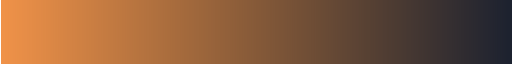

In [14]:
img = imread('BlueOrange.png')
pic = img[:, 0, :]
trackcmap = colors.LinearSegmentedColormap.from_list('NASA_blue', pic[::-1, :], N=pic.shape[0])
trackcmap

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [56]:
np.atleast_2d(1/ms[np.isfinite(ms)]**2).shape

(1, 541737)

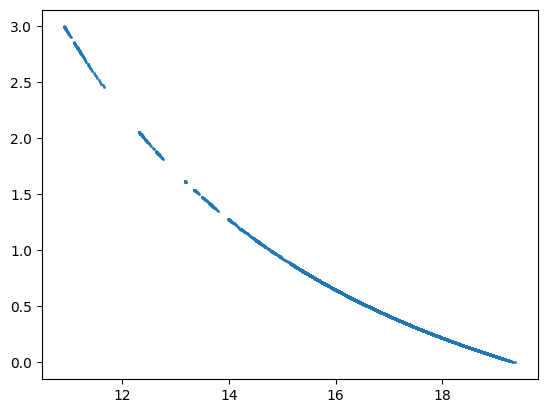

In [84]:
scaler = MinMaxScaler(feature_range=(0,3), clip=False)

ms = all_vmag.copy().values
aux = scaler.fit_transform(np.atleast_2d(1/ms[np.isfinite(ms)]**2).T, )
ms[np.isfinite(ms)] = aux.ravel()

plt.scatter(all_vmag.values, ms, s=1)
plt.show()

In [85]:
ms.shape

(1717, 28)

/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/Users/jimartin/miniforge3/envs/tess-asteroid-ml/lib/python3.10/site-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


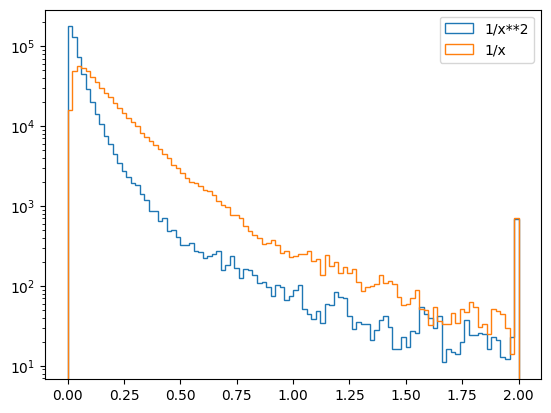

In [67]:
plt.hist(pd.DataFrame(scaler.fit_transform(1/all_vmag**5), columns=all_vmag.columns).values.ravel(), bins=100, log=True, label="1/x**2", histtype="step");
plt.hist(pd.DataFrame(scaler.fit_transform(1/all_vmag), columns=all_vmag.columns).values.ravel(), bins=100, log=True, label="1/x", histtype="step");
plt.legend()
plt.show()

In [73]:
[np.nanmin(all_lon)*0.8, np.nanmax(all_lon)*1.2], [np.nanmin(all_lat)*0.8, np.nanmax(all_lat)*1.2]

([-143.11886767065343, -99.33593145137836],
 [-62.886162824829626, -7.137736015000942])

In [91]:
def calculate_alpha(current_time, decay_window, power=3.0):
    """
    Returns an array of alpha values for every time step from t=0 to t=current_time.
    
    Parameters:
    - current_time (int): The current step of the simulation (e.g., 50).
    - decay_window (int): How far back the trace should last (e.g., 10).
    - power (float): 1.0 is linear. Higher values (e.g., 3.0) make the trace 
                     faint for longer and then "quickly increase" to 1.
    
    Returns:
    - np.array: Array of alpha values between 0.0 and 1.0. 
                Index 0 corresponds to time=0.
    """
    
    # 1. Generate the timeline array: [0, 1, 2, ..., current_time]
    times = np.arange(current_time + 1)
    
    # 2. Calculate the "age" of each time step relative to now
    # If current_time is 50, time 50 has age 0, time 40 has age 10.
    ages = current_time - times
    
    # 3. Normalize the age into a 0.0 - 1.0 score
    # We want 1.0 when age is 0 (now), and 0.0 when age is decay_window.
    scores = (decay_window - ages) / decay_window
    
    # 4. Clip the scores to remove negative values (older than window)
    # and ensure nothing exceeds 1.0.
    scores = np.clip(scores, 0, 1)
    
    # 5. Apply the power curve to satisfy "quickly increase" requirement
    alphas = np.power(scores, power)
    
    return alphas

In [92]:
isot0 = Time(time_array[0], scale="utc", format="jd")
all_sky = False
new_time = False
last_sector = 0
nccds = 16
nsectors = 13
projection = ccrs.Mollweide()
projection =  "rectilinear"

for tdx in tqdm(range(0, len(time_array)), total=len(time_array)):

    fig = plt.figure(figsize=(24, 12))
    ax = plt.axes([0.0, 0.0, 1.0, 1.0],
                  # projection=projection,
                 )
    if projection != "rectilinear":
        ax.spines['geo'].set_linewidth(0)

    if all_sky:
        for edgefile in edgefiles:
            elat, elon = np.loadtxt(edgefile, unpack=True)
            plt.scatter(elon, elat, 
                        c='w', alpha=0.01, zorder=-5,
                        marker='.', s=1, 
                        # transform=projection,
                       )
    else:
        plt.scatter([np.nanmin(all_lon)*0.8, np.nanmax(all_lon)*1.2], 
                    [np.nanmin(all_lat)*0.8, np.nanmax(all_lat)*1.2], 
                    c='w', alpha=0.01, zorder=-5,
                    marker='.', s=1, 
                    # transform=projection,
                   )        
    
    cnts = ax.text(
            0.95, 0.96, "", transform=fig.transFigure, 
            ha='right', va='top', multialignment='right',
            fontsize=40,
        )
    sec = sector_array[tdx]
    ffi_idx_i = (sec-1) * nccds
    ffi_idx_f = ffi_idx_i + nccds

    alpha = calculate_alpha(tdx, 9, power=3)

    ax.scatter(
        all_lon.values[:, :tdx], 
        all_lat.values[:, :tdx], 
        # c=all_vmag.values[:, :tdx],
        # cmap="tab:orange",
        c="tab:orange",
        s=ms[:, :tdx], 
        rasterized=True, 
        # transform=projection,
        alpha=alpha,
    )
    if sec == 1:
        sectxt = f"Sector 1"
    else:
        sectxt = f"Sector 1 - {sec}"
    isotf = Time(time_array[tdx], scale="utc", format="jd")
    sectxt = f"{sectxt}\n{isot0.iso[:10]} - {isotf.iso[:10]}"
    if new_time:
        date.remove()
    date = ax.text(
        0.95, 0.02, sectxt, transform=fig.transFigure, 
        ha='right', va='bottom', multialignment='right',
        fontsize=50,
    )
    counts_cum = counts[:sec].sum()
    astertxt = f"{counts_cum} Asteroids \nV < {maglim}"
    cnts.remove()
    cnts = ax.text(
        0.95, 0.96, astertxt, transform=fig.transFigure, 
        ha='right', va='top', multialignment='right',
        fontsize=50,
    )

    new_time = True
    plt.savefig(f"./figures/animation/fixed_bkg/tess_all-sky_sector_all_tracks_{tdx:03}.png", 
                transparent=False, format="png", bbox_inches="tight", dpi=200)
    plt.close()

    # if tdx == 2: break
    
    # plt.show()

100%|██████████████████████████████████████████████████████████████████████████| 28/28 [00:10<00:00,  2.61it/s]


In [93]:
alpha

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00137174,
       0.01097394, 0.03703704, 0.0877915 , 0.17146776, 0.2962963 ,
       0.47050754, 0.70233196, 1.        ])